In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../data/jeruk_balance_500.csv')
df

,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
0,7.75,216.4,0.51,11.1,Kalimantan,oranye,kemarau,Bagus
1,7.43,237.9,0.43,10.6,Jawa Tengah,kuning,kemarau,Bagus
2,7.82,195.1,0.60,12.9,Jawa Barat,oranye,hujan,Bagus
3,8.26,184.9,0.49,13.9,Kalimantan,oranye,hujan,Bagus
4,7.38,182.2,0.42,10.6,Jawa Barat,oranye,kemarau,Bagus
...,...,...,...,...,...,...,...,...
495,6.06,106.0,0.73,7.7,Jawa Tengah,hijau,kemarau,Jelek
496,5.50,108.8,0.92,10.4,Jawa Barat,hijau,kemarau,Jelek
497,5.50,95.5,1.05,8.4,Jawa Barat,hijau,hujan,Jelek
498,7.69,221.8,0.70,13.0,Jawa Barat,oranye,hujan,Bagus


In [51]:
print(df['asal_daerah'].unique())


<ArrowStringArray>
['Kalimantan', 'Jawa Tengah', 'Jawa Barat']
Length: 3, dtype: str


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diameter     500 non-null    float64
 1   berat        500 non-null    float64
 2   tebal_kulit  500 non-null    float64
 3   kadar_gula   500 non-null    float64
 4   asal_daerah  500 non-null    str    
 5   warna        500 non-null    str    
 6   musim_panen  500 non-null    str    
 7   kualitas     500 non-null    str    
dtypes: float64(4), str(4)
memory usage: 44.7 KB


In [31]:
df.describe()

,diameter,berat,tebal_kulit,kadar_gula
count,500.000000,500.000000,500.000000,500.000000
mean,6.514780,150.670600,0.730460,10.020200
std,0.955277,44.637103,0.252194,1.882291
min,3.990000,74.400000,0.270000,5.800000
25%,5.747500,106.000000,0.540000,8.600000
50%,6.540000,151.600000,0.690000,10.100000
75%,7.290000,188.050000,0.882500,11.500000
max,8.730000,277.100000,1.620000,14.600000


In [32]:
print("--- Asal Daerah ---")
print(df['asal_daerah'].value_counts())
print("\n--- Warna ---")
print(df['warna'].value_counts())
print("\n--- Kualitas ---")
print(df['kualitas'].value_counts())
print("\n--- Musim Panen ---")
print(df['musim_panen'].value_counts())

--- Asal Daerah ---
asal_daerah
Jawa Tengah    194
Kalimantan     163
Jawa Barat     143
Name: count, dtype: int64

--- Warna ---
warna
hijau     255
kuning    148
oranye     97
Name: count, dtype: int64

--- Kualitas ---
kualitas
Bagus     168
Sedang    166
Jelek     166
Name: count, dtype: int64

--- Musim Panen ---
musim_panen
kemarau    251
hujan      249
Name: count, dtype: int64


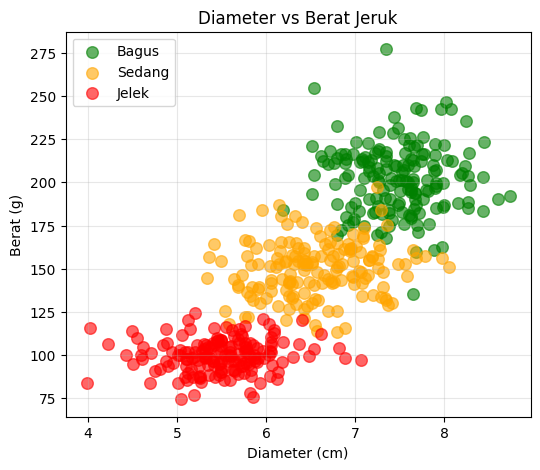

In [33]:
bagus = df[df['kualitas'] == 'Bagus']
sedang = df[df['kualitas'] == 'Sedang']
jelek = df[df['kualitas'] == 'Jelek']

plt.figure(figsize=(6, 5))
plt.scatter(bagus['diameter'], bagus['berat'], s=70, alpha=0.6, color='green', label='Bagus')
plt.scatter(sedang['diameter'], sedang['berat'], s=70, alpha=0.6, color='orange', label='Sedang')
plt.scatter(jelek['diameter'], jelek['berat'], s=70, alpha=0.6, color='red', label='Jelek')
plt.title('Diameter vs Berat Jeruk')
plt.xlabel('Diameter (cm)')
plt.ylabel('Berat (g)')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.3)
plt.show()

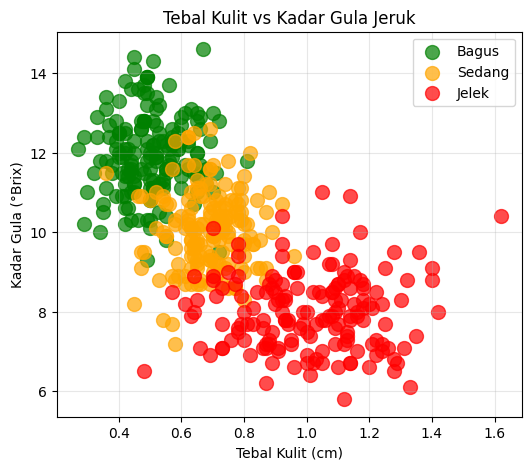

In [34]:
bagus = df[df['kualitas'] == 'Bagus']
sedang = df[df['kualitas'] == 'Sedang']
jelek = df[df['kualitas'] == 'Jelek']

plt.figure(figsize=(6, 5))

plt.scatter(bagus['tebal_kulit'], bagus['kadar_gula'], s=100, alpha=0.7, color='green', label='Bagus')
plt.scatter(sedang['tebal_kulit'], sedang['kadar_gula'], s=100, alpha=0.7, color='orange', label='Sedang')
plt.scatter(jelek['tebal_kulit'], jelek['kadar_gula'], s=100, alpha=0.7, color='red', label='Jelek')
plt.title('Tebal Kulit vs Kadar Gula Jeruk')
plt.xlabel('Tebal Kulit (cm)')
plt.ylabel('Kadar Gula (°Brix)')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.3)
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


X = df[["diameter", "berat", "tebal_kulit", "kadar_gula", "asal_daerah", "warna", "musim_panen"]]
Y = df["kualitas"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


numeric_columns = ["diameter", "berat", "tebal_kulit", "kadar_gula"]
categorical_columns = ["asal_daerah", "musim_panen"]
ordinal_columns = ["warna"]

warna_order = ['hijau', 'kuning', 'oranye']
ordinal_order = [warna_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns),
        ]
    )

model = Pipeline(
    steps=[
        ("preprocessing",preprocessing),
        ("model", LogisticRegression())
    ]
)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred))

Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

       Bagus       1.00      1.00      1.00        35
       Jelek       1.00      0.98      0.99        41
      Sedang       0.96      1.00      0.98        24

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100


Confusion Matrix:
 [[35  0  0]
 [ 0 40  1]
 [ 0  0 24]]


In [36]:
new_data = pd.DataFrame([[7.89, 200, 0.35, 10, "Jawa Barat", "hijau", "kemarau"]],
    columns=[
        "diameter", "berat", "tebal_kulit", "kadar_gula", "asal_daerah", "warna", "musim_panen"
    ])
prediksi = model.predict(new_data)[0]
presentase = max(model.predict_proba(new_data)[0])
print(f"Model memprediksi kualitas jeruk sebagai '{prediksi}' dengan presentase {presentase*100:.2f}%")

Model memprediksi kualitas jeruk sebagai 'Bagus' dengan presentase 83.24%


In [37]:
import joblib

joblib.dump(model, 'orange_quality_model.joblib')


['orange_quality_model.joblib']